---
title: "Data Cleaning"
format:
    html: 
        code-fold: false
        embed-resources: true
---

{{< include overview.qmd >}} 

{{< include method.qmd >}} 

Below, we will show how you how we cleaned the datasets we used for this project. We cleaned a significant number of datasets. 

### Navigation
- [Go to Accuracy Prediction Section](##Accuracy-Prediction-Cleaning)
- [Go to Reliability Section](##Reliability-Cleaning)
- [Go to Financial Statement Section](##Financial-Statement-Cleaning)
- [Go to Alerts Section](##Alert-Cleaning)
- [Go to RSS Feed Section](##Accuracy-Prediction-Cleaning)

---


If you need a refresher on the data sources, visit the link below:

**[Visit Data Source Information Here](../data-collection/overview.qmd)**

**Import Libraries**: 

In [90]:
import missingno as msno
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from datetime import datetime
import re 


## Accuracy Prediction Cleaning

We handled the accuracy prediction dataset with these steps: 

1) Cleaned the "bin" column by separating the range values into their own columns- a column for the lower minute range of the time frame bin and another column for the higher minute range of time fram bin
2) Converted values in the "weekly" column into datetime format
3) Converted columns that were object data types to their respective string and integer data types
4) Created a column for pre and post 2021 binary values
    - Convert the date values under "weekly" column to numeric, then use if-else condition to convert all values before numeric version of 1/1/2021 to "0" and all dates after numeric version of 1/1/2021 to "1".
        - We decided to set 1/1/2021 as the marker for before and after timeline because the renovation program for the MBTA system began in 1/1/2021.

Please view the code below! 

**Load dataset & View raw version**

In [91]:
#load the "rapid_transit_and_bus_prediction_accuracy_data.csv" file
ride_accuracy = pd.read_csv("../../data/raw-data/rapid_transit_and_bus_prediction_accuracy_data.csv")

#convert csv file into a dataframe
ride_accuracy_df = pd.DataFrame(ride_accuracy)

#print the first 10 rows of dataframe
print(ride_accuracy_df.head(10))

#print shape of dataframe
print(ride_accuracy_df.shape)

       weekly mode route_id        bin arrival_departure  num_predictions  \
0  2020-08-06  bus      NaN    0-3 min         departure           233967   
1  2020-08-06  bus      NaN    3-6 min         departure           227406   
2  2020-08-06  bus      NaN   6-12 min         departure           445848   
3  2020-08-06  bus      NaN  12-30 min         departure          1261843   
4  2020-08-13  bus      NaN    0-3 min         departure           240187   
5  2020-08-13  bus      NaN    3-6 min         departure           233322   
6  2020-08-13  bus      NaN   6-12 min         departure           455828   
7  2020-08-13  bus      NaN  12-30 min         departure          1299411   
8  2020-08-20  bus      NaN    0-3 min         departure           234504   
9  2020-08-20  bus      NaN    3-6 min         departure           227992   

   num_accurate_predictions  
0                    183615  
1                    178297  
2                    368421  
3                   1101363  
4 

**Identify Missing Values**

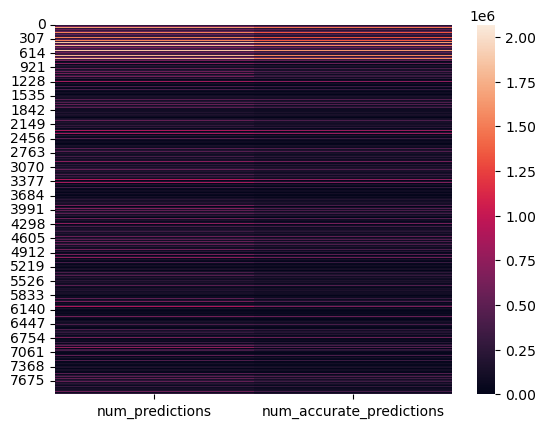

In [92]:
#subset dataframe to create a heatmap to visualize missing data. Keep numeric value columns
ride_accuracy_df_subset = ride_accuracy_df[[ "num_predictions", "num_accurate_predictions" ]]

#create heatmap of datafram before dropping NA values
sns.heatmap(ride_accuracy_df_subset)
plt.show() #show heatmap

**Identifying Outlier**

       num_predictions  num_accurate_predictions
count     7.964000e+03              7.964000e+03
mean      2.411512e+05              1.988910e+05
std       2.944540e+05              2.492383e+05
min       0.000000e+00              0.000000e+00
25%       8.053400e+04              7.106275e+04
50%       1.306255e+05              1.100235e+05
75%       3.003818e+05              2.470378e+05
max       2.070137e+06              1.818970e+06


<Axes: >

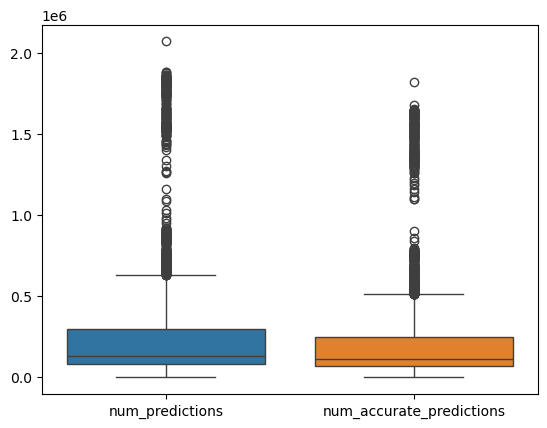

In [93]:
#find outliers before dropping na using describe()
print(ride_accuracy_df.describe())

#create boxplot of dataframe with na to visualize outliers
sns.boxplot(data=ride_accuracy_df)

By looking at this box plot, we found plenty of outliers, which are represented by the outlined circles. As a 

**Handling Null Values**

In [94]:
#find na values in the columns
ride_accuracy_df_na = ride_accuracy_df.isna().sum()
print(ride_accuracy_df_na)

#drop rows with NA values from the route_id column because it is the only column with na values
ride_accuracy_df_dropna = ride_accuracy_df
ride_accuracy_df_dropna.dropna(inplace=True)
print(ride_accuracy_df_dropna.shape)

weekly                        0
mode                          0
route_id                    780
bin                           0
arrival_departure             0
num_predictions               0
num_accurate_predictions      0
dtype: int64
(7184, 7)


**Datatype Transformation**

In [95]:
#check the data types of columns
print("----Data Types Before Transformation-----")
print(ride_accuracy_df_dropna.dtypes)

#convert "weekly" column data type to datetime
ride_accuracy_df_dropna["weekly"] = pd.to_datetime(ride_accuracy_df_dropna["weekly"])
#convert "mode" column data type to string
ride_accuracy_df_dropna["mode"] = ride_accuracy_df_dropna["mode"].astype(str)
#convert "route_id" column data type to string
ride_accuracy_df_dropna["route_id"] = ride_accuracy_df_dropna["route_id"].astype(str)
#convert "bin" column data type to string
ride_accuracy_df_dropna["bin"] = ride_accuracy_df_dropna["bin"].astype(str)
#convert "arrival_departure" column data type to string
ride_accuracy_df_dropna["arrival_departure"] = ride_accuracy_df_dropna["arrival_departure"].astype(str)

#check data types of columns after transformation
print("----Data Types After Transformation-----")
print(ride_accuracy_df_dropna.dtypes)

----Data Types Before Transformation-----
weekly                      object
mode                        object
route_id                    object
bin                         object
arrival_departure           object
num_predictions              int64
num_accurate_predictions     int64
dtype: object
----Data Types After Transformation-----
weekly                      datetime64[ns]
mode                                object
route_id                            object
bin                                 object
arrival_departure                   object
num_predictions                      int64
num_accurate_predictions             int64
dtype: object


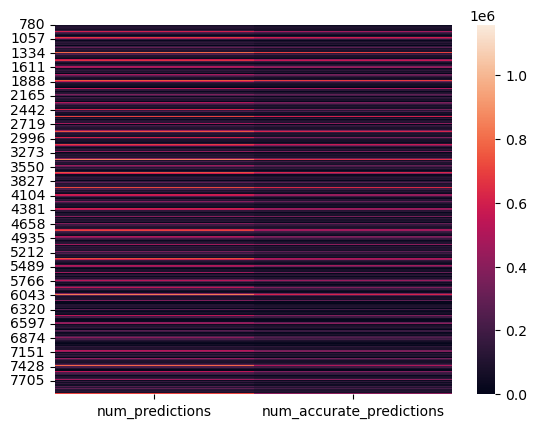

In [96]:
#subset dataframe to create a heatmap to visualize missing data. Keep numeric value columns
ride_accuracy_df_no_na_subset = ride_accuracy_df_dropna[[ "num_predictions", "num_accurate_predictions" ]]

#create heatmap of dataframe after dropping NA values
sns.heatmap(ride_accuracy_df_no_na_subset)
plt.show() #show heatmap

                              weekly  num_predictions  \
count                           7184     7.184000e+03   
mean   2022-09-09 15:45:18.040088832     1.900083e+05   
min              2020-08-03 00:00:00     0.000000e+00   
25%              2021-08-30 00:00:00     7.617800e+04   
50%              2022-09-26 00:00:00     1.199255e+05   
75%              2023-09-25 00:00:00     2.237600e+05   
max              2024-08-26 00:00:00     1.158573e+06   
std                              NaN     1.842277e+05   

       num_accurate_predictions  
count               7184.000000  
mean              154576.004176  
min                    0.000000  
25%                67576.000000  
50%               101258.000000  
75%               187399.250000  
max               904424.000000  
std               144457.231305  


<Axes: >

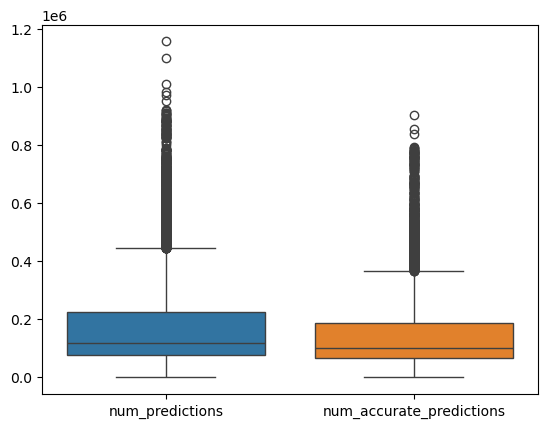

In [97]:
#find outliers after dropping na using describe()
print(ride_accuracy_df_dropna.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=ride_accuracy_df_dropna)

**Cleaning Features**

In [98]:
#split the "bin" column based on space character to separate the numerical range and the min unit
ride_accuracy_df_dropna[["a", "b"]] = ride_accuracy_df_dropna["bin"].str.split(" ", expand = True)
print(ride_accuracy_df_dropna.head())

#split the "a" column based on the "-" character to get a low range and high range of the bin values
ride_accuracy_df_dropna[["Low Range Bin Time (min)", "High Range Bin Time (min)"]] = ride_accuracy_df_dropna["a"].str.split("-", expand = True)
print(ride_accuracy_df_dropna.head())

#remove the unneeded "a" and "b" columns
ride_accuracy_df_drop_cols = ride_accuracy_df_dropna
ride_accuracy_df_drop_cols = ride_accuracy_df_drop_cols.drop(['a', 'b'], axis=1)
print(ride_accuracy_df_drop_cols.head(10))

        weekly    mode route_id        bin arrival_departure  num_predictions  \
780 2020-08-03  subway     Blue    0-3 min           blended            63612   
781 2020-08-03  subway     Blue    3-6 min           blended            65346   
782 2020-08-03  subway     Blue   6-12 min           blended           124158   
783 2020-08-03  subway     Blue  12-30 min           blended           350575   
784 2020-08-03  subway  Green-B    0-3 min           blended           144067   

     num_accurate_predictions      a    b  
780                     58116    0-3  min  
781                     58809    3-6  min  
782                    112668   6-12  min  
783                    314248  12-30  min  
784                    117550    0-3  min  
        weekly    mode route_id        bin arrival_departure  num_predictions  \
780 2020-08-03  subway     Blue    0-3 min           blended            63612   
781 2020-08-03  subway     Blue    3-6 min           blended            65346   
782 20

**Export Cleaned Sheet**

In [99]:
ride_accuracy_df_drop_cols.to_csv("../../data/processed-data/Clean_Ride_Accuracy.csv")

**Transforming to Binary** 

In [100]:
#alternative analysis: add a column to the dataframe for binary classification target
ride_accuracy_df_binary = ride_accuracy_df_drop_cols

print(ride_accuracy_df_binary["weekly"].dtype) #check id column is datatime type

#we want to observe all dates after 2022-01-01 as "1"'s and all dates before 2022-01-01 as "0"'s
#split the data pre and post 2022-01-01 because that was the year the MBTA infrastructure renovation program began
date_to_string = "2022-01-01" #set variable to 2022-01-01 to find its numeric format
date_convert = datetime.strptime(date_to_string, "%Y-%m-%d") #convert string date to datetime format
print(type(date_convert)) #check if it is datetime format
num_date = int(date_convert.timestamp()) #convert datetime to an integer
#num_date_result = num_date//10**9
#print(num_date_result)
print(num_date) #print the numeric conversion of the 2022-01-01 date which equals 1641013200, easier for if else statement to transform dates into binary values


ride_accuracy_df_binary["Pre and Post 2021"] = ride_accuracy_df_binary["weekly"].astype('int64')//10**9 #convert dates in the "weekly" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(ride_accuracy_df_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

ride_accuracy_df_binary["Pre and Post 2021 Binary"] = np.where(ride_accuracy_df_binary["Pre and Post 2021"] > 1641013200, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(ride_accuracy_df_binary["Pre and Post 2021 Binary"].head()) #print first few rows of binary dates


datetime64[ns]
<class 'datetime.datetime'>
1641013200
780    1596412800
781    1596412800
782    1596412800
783    1596412800
784    1596412800
Name: Pre and Post 2021, dtype: int64
780    0
781    0
782    0
783    0
784    0
Name: Pre and Post 2021 Binary, dtype: int64


In [101]:
#export clean binary data csv file to processed-data folder
ride_accuracy_df_binary.to_csv("../../data/processed-data/Clean_Ride_Accuracy_Binary.csv")

## Reliability Cleaning

We handled the reliability dataset with these steps: 

1) Clean the "trip_date" column be separating the date and time values into their own columns
2) Convert the dates into correct datetime data format
3) Convert columns that were object data types to their respective string and integer data types
4) Created a column for pre and post 2021 binary values
    - Convert the date values under "weekly" column to numeric, then use if-else condition to convert all values before numeric version of 1/1/2021 to "0" and all dates after numeric version of 1/1/2021 to "1".
      

Please view the code below! 

In [102]:
ride_reliability = pd.read_csv("../../data/raw-data/MBTA_The_RIDE_Reliability.csv")

#convert csv file into a dataframe
ride_reliability_df = pd.DataFrame(ride_reliability)

#print the first 10 rows of dataframe
print(ride_reliability_df.head(10))

#print shape of dataframe
print(ride_reliability_df.shape)

                trip_date  ontime_trip_count  trip_count  ObjectId
0  2014/07/01 04:00:00+00               5479        5884         1
1  2014/07/02 04:00:00+00               5297        5612         2
2  2014/07/03 04:00:00+00               4959        5306         3
3  2014/07/04 04:00:00+00               1530        1558         4
4  2014/07/05 04:00:00+00               2420        2580         5
5  2014/07/06 04:00:00+00               2202        2369         6
6  2014/07/07 04:00:00+00               5048        5332         7
7  2014/07/08 04:00:00+00               5492        5925         8
8  2014/07/09 04:00:00+00               5668        6163         9
9  2014/07/10 04:00:00+00               5487        6027        10
(3681, 4)


In [103]:
#find na values in the columns
ride_reliability_df_na = ride_reliability_df.isna().sum()
print(ride_reliability_df_na) #no NA values in the dataframe

trip_date            0
ontime_trip_count    0
trip_count           0
ObjectId             0
dtype: int64


In [104]:
print(type(ride_reliability_df))
print(ride_reliability_df["trip_date"].dtypes)
print(ride_reliability_df["ontime_trip_count"].dtypes)
print(ride_reliability_df["trip_count"].dtypes)
print(ride_reliability_df["ObjectId"].dtypes)


#convert the "trip_date" column to string data type to prepare for splitting
ride_reliability_df["trip_date"] = ride_reliability_df["trip_date"].astype(str)

print("After converting to string type: ", ride_reliability_df["trip_date"].dtypes)

<class 'pandas.core.frame.DataFrame'>
object
int64
int64
int64
After converting to string type:  object


In [105]:
#split the "trip_date" column based on space to separate date and time
ride_reliability_df[["Date", "Time"]] = ride_reliability_df["trip_date"].str.split(" ", expand = True)
print(ride_reliability_df.head())

#convert "Date" column to YYYY-MM-DD date format to match the column in the cleaned Clean_Ride_Accuracy.csv file
ride_reliability_df["Date"] = pd.to_datetime(ride_reliability_df["Date"]) #convert "Date" column to dateime format

ride_reliability_df["Date"] = ride_reliability_df["Date"].dt.strftime('%Y-%m-%d') #reformat "Date" value as yyyy-mm-dd

print(ride_reliability_df["Date"].head()) #print first few rows of reformatted Date column

                trip_date  ontime_trip_count  trip_count  ObjectId  \
0  2014/07/01 04:00:00+00               5479        5884         1   
1  2014/07/02 04:00:00+00               5297        5612         2   
2  2014/07/03 04:00:00+00               4959        5306         3   
3  2014/07/04 04:00:00+00               1530        1558         4   
4  2014/07/05 04:00:00+00               2420        2580         5   

         Date         Time  
0  2014/07/01  04:00:00+00  
1  2014/07/02  04:00:00+00  
2  2014/07/03  04:00:00+00  
3  2014/07/04  04:00:00+00  
4  2014/07/05  04:00:00+00  
0    2014-07-01
1    2014-07-02
2    2014-07-03
3    2014-07-04
4    2014-07-05
Name: Date, dtype: object


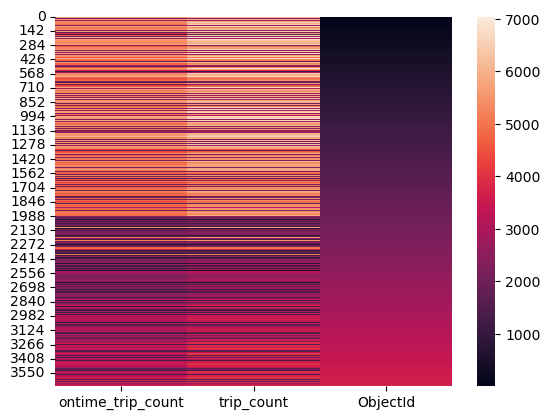

In [106]:
#subset dataframe to create a heatmap to visualize missing data - even though there are no missing data. Keep numeric value columns
ride_reliability_df_subset = ride_reliability_df[[ "ontime_trip_count", "trip_count", "ObjectId"]]

#create heatmap of dataframe, no NA values, no NA values needed to drop
sns.heatmap(ride_reliability_df_subset)
plt.show() #show heatmap

       ontime_trip_count   trip_count     ObjectId
count        3681.000000  3681.000000  3681.000000
mean         3349.814453  3730.092910  1841.000000
std          1541.218043  1759.167967  1062.757498
min           150.000000   163.000000     1.000000
25%          2190.000000  2353.000000   921.000000
50%          3005.000000  3362.000000  1841.000000
75%          4943.000000  5529.000000  2761.000000
max          6181.000000  7045.000000  3681.000000


<Axes: >

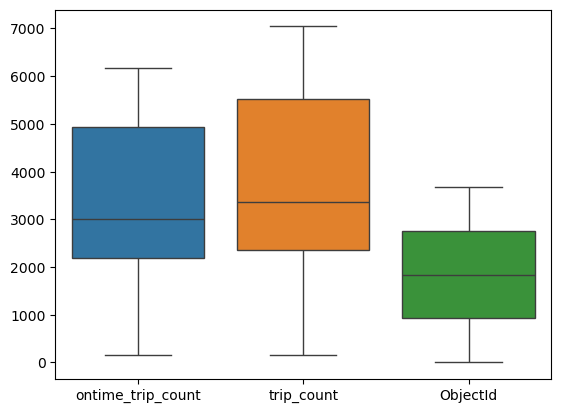

In [107]:
#find outliers using describe()
print(ride_reliability_df.describe())

#create boxplot of dataframe to visualize outliers
sns.boxplot(data=ride_reliability_df)

In [108]:
#export clean csv file to processed-data folder
ride_reliability_df.to_csv("../../data/processed-data/Clean_Ride_Reliability.csv")

## Alert Cleaning 

We handled the alert dataset with these steps: 
1) Load Dataset 
2) Handle Null Values
3) Subset / filter out certain features
4) Detect Potential Outliers 
5) Extract affected direction and stops from description as new columns 
6) Clean text for formatting 
7) Export file to processed-data file 

Please view the code below! 

In [163]:
# Load the dataset
file_path = '../../data/raw-data/merged_alerts.csv'  

merged_alerts = pd.read_csv(file_path)
print(merged_alerts.head()) # viewed the pre-processed dataset 
shape = merged_alerts.shape
print(shape)
data_types = merged_alerts.dtypes
print(data_types)


/var/folders/wx/8tzhq3ln59j92r3pl8v47rfw0000gn/T/ipykernel_83572/3812117322.py:4: DtypeWarning: Columns (16,25) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_alerts = pd.read_csv(file_path)


   alert_id        cause cause_detail  effect effect_detail severity_level  \
0    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
1    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
2    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
3    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   
4    483702  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE   

   severity                                             header description  \
0         7  Route 117 inbound trips all day on Saturdays a...         NaN   
1         7  Route 117 inbound trips all day on Saturdays a...         NaN   
2         7  Route 117 inbound trips all day on Saturdays a...         NaN   
3         7  Route 117 inbound trips all day on Saturdays a...         NaN   
4         7  Route 117 inbound trips all day on Saturdays a...         NaN   

  alert_lifecycle  ... active_period_start_dt  active_period_e

**Handle Null Values** 

    - visualize null 
    - evaluate if columns with many null are essential or can be ommitted


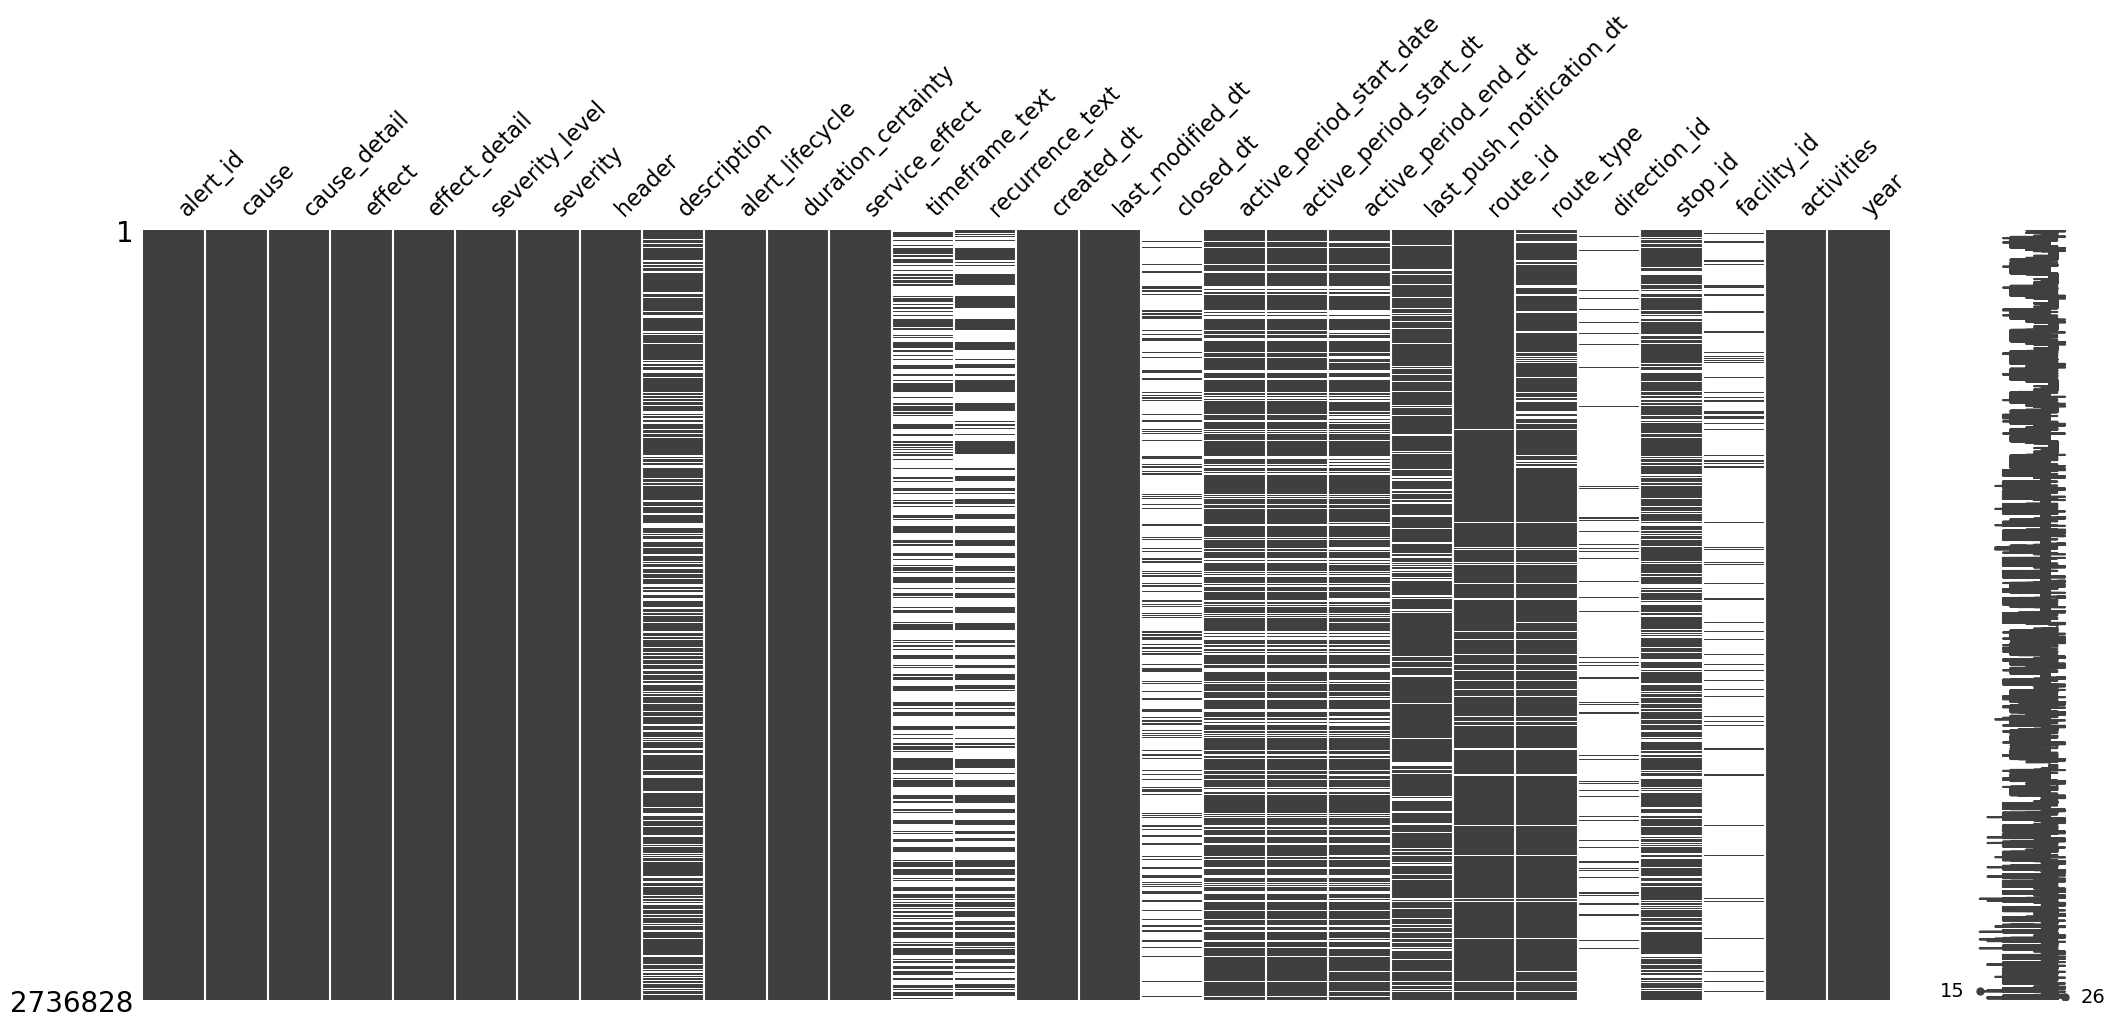

In [164]:
msno.matrix(merged_alerts) # visualized it as a matrix 
plt.show()

In [165]:
missing_values_count = merged_alerts.isnull().sum()
print(missing_values_count)

alert_id                           0
cause                              0
cause_detail                       0
effect                             0
effect_detail                      0
severity_level                     0
severity                           0
header                             0
description                   604174
alert_lifecycle                  683
duration_certainty                 0
service_effect                   371
timeframe_text               1620140
recurrence_text              1495277
created_dt                         0
last_modified_dt                   0
closed_dt                    2168374
active_period_start_date      570060
active_period_start_dt        570060
active_period_end_dt          686506
last_push_notification_dt     417188
route_id                      108719
route_type                    225809
direction_id                 2489627
stop_id                       594191
facility_id                  2511076
activities                        47
y

**Accessing Relevant Features** 

Below is my assessment, given our information about nulls and the context, when filtering features. 

The following are features with high missing values: 
- `description` (604,174 missing)
- `timeframe_text` (1,620,140 missing)
- `recurrence_text` (1,495,277 missing)
- `closed_dt` (2,168,374 missing)
- `direction_id` (2,489,627 missing)
- `facility_id` (2,511,076 missing)


---


These columns have substantial missing values. However, some of these columns are critical to understanding lifecycle events.

**Critical Columns Contextually**
- `description`: Shows what stops are affected, inbound/outbound.  
- `recurrence_text`: Explains what dates are affected. However, over 1 million are missing, which is a significantly high null, so I will remove this column. 


---


**Non-Essential Columns**
- `timeframe_text`  
- `closed_dt`  
- `direction_id`  
- `facility_id`  

---

**Contextually Unneeded Columns**
- `alert_id`  
- `header`  
- `alert_lifecycle`  
- `duration_certainty`  
- `created_dt`  
- `last_modified_dt`  
- `closed_dt`  
- `active_period_start_dt`  
- `active_period_end_dt`  
- `last_push_notification_dt`  
- `service_effect`  
- `direction_id`  
- `stop_id`  
- `facility_id`  

---

**Necessary Columns**
- `cause`: Cause of the alert.  
- `cause_detail`: Description of the alert.  
- `effect`: The effect of the alert on the affected entity.  
- `effect_detail`: Description of the effect.  
- `severity_level`: Severity level of the alert, expressed as a categorical value.  
- `severity`: Numeric severity (0 to 10).  
- `description`: Shows stops and routes affected.  
- `route_id`: Shows the specific routes affected.  
- `route_type`: Shows the type of route affected.
- `stop_id`L shows specific spots affected. 


In [166]:

# Check for missing values and their distribution
missing_values = merged_alerts.isnull().sum()

# Display basic statistics for numeric columns
numeric_stats = merged_alerts.describe()

# Display basic statistics for categorical columns
categorical_columns = merged_alerts.select_dtypes(include=['object'])
categorical_stats = categorical_columns.describe()


In [171]:
# Columns to drop
columns_to_drop = [
    'alert_id',                
    'duration_certainty',     
    'recurrence_text',         
    'created_dt',              
    'last_modified_dt',       
    'closed_dt',              
    'active_period_start_date', 
    'active_period_start_dt',
    'active_period_end_dt',    
    'last_push_notification_dt', 
    'direction_id',            
    'facility_id',             
    'timeframe_text',
    'route_type',
    'service_effect',
    'alert_lifecycle',
    'activities',
    'header'
]

# Drop the irrelevant columns
merged_alerts_cleaned = merged_alerts.drop(columns=columns_to_drop, errors='ignore')

# Impute Blank Descriptions with unknown
merged_alerts_cleaned['description'].fillna('Unknown', inplace=True)

# For 'route_id', fill missing with "Unspecified"
merged_alerts_cleaned['route_id'].fillna('Unspecified', inplace=True)

merged_alerts_cleaned['stop_id'].fillna('Unspecified', inplace=True)

# Display results after cleaning
print(f"Remaining columns: {merged_alerts_cleaned.columns.tolist()}")
print(f"Shape after cleaning: {merged_alerts_cleaned.shape}")
print(f"Missing values after cleaning: \n{merged_alerts_cleaned.isnull().sum()}")
print(merged_alerts_cleaned.head(5))

Remaining columns: ['cause', 'cause_detail', 'effect', 'effect_detail', 'severity_level', 'severity', 'description', 'route_id', 'stop_id', 'year']
Shape after cleaning: (2736828, 10)
Missing values after cleaning: 
cause             0
cause_detail      0
effect            0
effect_detail     0
severity_level    0
severity          0
description       0
route_id          0
stop_id           0
year              0
dtype: int64
         cause cause_detail  effect effect_detail severity_level  severity  \
0  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
1  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
2  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
3  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   
4  MAINTENANCE  MAINTENANCE  DETOUR        DETOUR         SEVERE         7   

  description route_id      stop_id  year  
0     Unknown      117  Unspecified  2024  
1     Unknown 

In [172]:
# Output basic statistics after cleaning
print("Numeric Statistics:")
print(merged_alerts_cleaned.describe())

print("Categorical Statistics:")
categorical_columns_cleaned = merged_alerts_cleaned.select_dtypes(include=['object'])
print(categorical_columns_cleaned.describe())

Numeric Statistics:
           severity          year
count  2.736828e+06  2.736828e+06
mean   3.752940e+00  2.022461e+03
std    3.155161e+00  1.364026e+00
min    0.000000e+00  2.020000e+03
25%    1.000000e+00  2.021000e+03
50%    3.000000e+00  2.023000e+03
75%    7.000000e+00  2.024000e+03
max    1.000000e+01  2.024000e+03
Categorical Statistics:
                cause   cause_detail        effect effect_detail  \
count         2736828        2736828       2736828       2736828   
unique             11             43             8            25   
top     UNKNOWN_CAUSE  UNKNOWN_CAUSE  OTHER_EFFECT         DELAY   
freq          1173449        1173449       1200557        897785   

       severity_level description      route_id      stop_id  
count         2736828     2736828       2736828      2736828  
unique              3       13461           417         7225  
top            SEVERE     Unknown  CR-Worcester  Unspecified  
freq          1117158      604174        288912       594

**Thoughts on Handling Outlier** 

Severity is the only value that should be looked at for outliers. However, we must think about the severity outliers representing real world events, that is severity values indicate MAJOR disruption (with grave consequences like death or injury). These should not be removed, since they provide valuable information about performance. Outliers should only be removd if there are data-entry errors. 

Because we are keeping the outliers, we should analyze to understand the distribution of outlier data. Below is a box plot, which displays the distribution of outliers. 

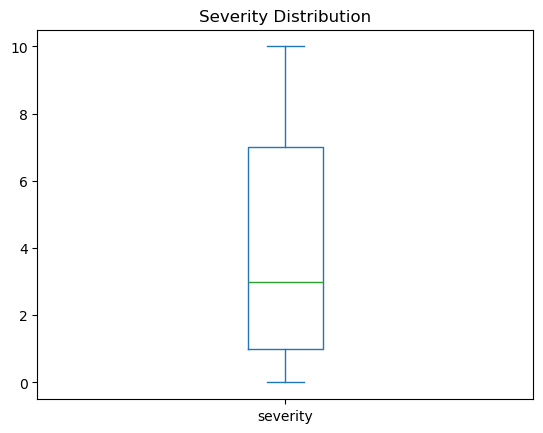

In [173]:
merged_alerts_cleaned['severity'].plot(kind='box', title='Severity Distribution')
plt.show()

**Thoughts**: The whiskers extend to the minimum and maximum values within 1.5 times the IQR. Therefore, there are no points outside the whiskers, indicating that all the values for severity fall within the expected range of 0–10. We will expand more on the alerts in the EDA section. 

**Extracting Affected Direction and Stops from Description** 

In [174]:
def extract_direction(description):
    if "Affected direction:" in description:
        try:
            return description.split("Affected direction:")[1].split("\n")[0].strip()
        except IndexError:
            return None
    return None

def extract_stops(description):
    if "Affected stops:" in description:
        try:
            stops = description.split("Affected stops:")[1].replace("\r", "").strip().split("\n")
            # Deduplicate stops
            stops = list(set([stop.strip() for stop in stops if stop.strip()]))
            return stops
        except IndexError:
            return None
    return None

merged_alerts_cleaned['affected_direction'] = merged_alerts_cleaned['description'].apply(extract_direction)
merged_alerts_cleaned['affected_stops'] = merged_alerts_cleaned['description'].apply(extract_stops)

print(merged_alerts_cleaned[['description', 'affected_direction', 'affected_stops']].head())

# Count rows where 'affected_direction' and 'affected_stops' are not None or NaN
affected_direction_count = merged_alerts_cleaned['affected_direction'].notna().sum()
affected_stops_count = merged_alerts_cleaned['affected_stops'].notna().sum()
description_count = (merged_alerts_cleaned['description'] != "Unknown").sum()


# Print the results
print(f"Number of rows with description as known: {description_count}")
print(f"Number of rows with values in 'affected_direction' (not 'None'): {affected_direction_count}")
print(f"Number of rows with values in 'affected_stops' (not 'None'): {affected_stops_count}")



  description affected_direction affected_stops
0     Unknown               None           None
1     Unknown               None           None
2     Unknown               None           None
3     Unknown               None           None
4     Unknown               None           None
Number of rows with description as known: 2132654
Number of rows with values in 'affected_direction' (not 'None'): 680508
Number of rows with values in 'affected_stops' (not 'None'): 1362444


**Clean texts** 

In [175]:
# Function to clean text
def clean_text(text):
    if pd.isna(text):  # Check for NaN
        return None
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    text = re.sub(r'_', ' ', text)  # Replace underscores with spaces
    return text

# Cleaning each column explicitly
merged_alerts_cleaned['cause'] = merged_alerts_cleaned['cause'].apply(clean_text)
merged_alerts_cleaned['cause_detail'] = merged_alerts_cleaned['cause_detail'].apply(clean_text)
merged_alerts_cleaned['effect'] = merged_alerts_cleaned['effect'].apply(clean_text)
merged_alerts_cleaned['effect_detail'] = merged_alerts_cleaned['effect_detail'].apply(clean_text)


print(merged_alerts_cleaned.head(5))



         cause cause_detail  effect effect_detail severity_level  severity  \
0  maintenance  maintenance  detour        detour         SEVERE         7   
1  maintenance  maintenance  detour        detour         SEVERE         7   
2  maintenance  maintenance  detour        detour         SEVERE         7   
3  maintenance  maintenance  detour        detour         SEVERE         7   
4  maintenance  maintenance  detour        detour         SEVERE         7   

  description route_id      stop_id  year affected_direction affected_stops  
0     Unknown      117  Unspecified  2024               None           None  
1     Unknown      117  Unspecified  2024               None           None  
2     Unknown      117  Unspecified  2024               None           None  
3     Unknown      117  Unspecified  2024               None           None  
4     Unknown      117  Unspecified  2024               None           None  


In [176]:
output_file_path = '../../data/processed-data/processed_alerts.csv'
merged_alerts_cleaned.to_csv(output_file_path, index=False)

print(f"Cleaned data successfully saved to: {output_file_path}")


Cleaned data successfully saved to: ../../data/processed-data/processed_alerts.csv


## News Cleaning 

We handled the news dataset with these steps: 
1) Load Dataset 
2) Choose significant features and ouput them as part of a csv  
3) Cleaned datatime 
4) Exported to processed-data file 

Please view the code below! 

In [119]:
import json

def extract_news_to_csv(json_file_path, output_csv_path):
    try:
        # Load the JSON data
        with open(json_file_path, 'r') as file:
            data = json.load(file)

        # Extract relevant fields
        simplified_news = []
        for news in data:
            simplified_news.append({
                "title": news.get("title", "N/A"),
                "date": news.get("date", "N/A"),
                "source_name": news.get("source", {}).get("name", "N/A"),
            })

        # Convert to a pandas DataFrame
        news_df = pd.DataFrame(simplified_news)

        # Save to a CSV file
        news_df.to_csv(output_csv_path, index=False)
        print(f"CSV file successfully saved to: {output_csv_path}")

    except FileNotFoundError:
        print(f"File not found: {json_file_path}")
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {json_file_path}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


json_file_path = "../../data/raw-data/google_news_results.json"  
output_csv_path = "../../data/raw-data/google_news_revised.csv" 

extract_news_to_csv(json_file_path, output_csv_path)



CSV file successfully saved to: ../../data/raw-data/google_news_revised.csv


**Clean up datetime**

In [120]:
from datetime import datetime
def clean_date(time):
    # Parse the datetime string
    parsed_date = datetime.strptime(time.split(",")[0], "%m/%d/%Y")
    # Format back to just the date
    return parsed_date.strftime("%m/%d/%Y")

news_csv = pd.read_csv("../../data/raw-data/google_news_revised.csv")

news_csv['cleaned_date'] = news_csv['date'].apply(clean_date)
print(news_csv[['date', 'cleaned_date']].head())


                              date cleaned_date
0  12/16/2024, 01:52 AM, +0000 UTC   12/16/2024
1  12/16/2024, 03:25 AM, +0000 UTC   12/16/2024
2  12/15/2024, 07:18 PM, +0000 UTC   12/15/2024
3  12/13/2024, 05:12 PM, +0000 UTC   12/13/2024
4  12/13/2024, 12:28 AM, +0000 UTC   12/13/2024


In [121]:
news_csv['title'] = news_csv['title'].apply(clean_text)

output_file_path = '../../data/processed-data/processed_news.csv'
news_csv.to_csv(output_file_path, index=False)

print(f"Cleaned data successfully saved to: {output_file_path}")


Cleaned data successfully saved to: ../../data/processed-data/processed_news.csv


## Financial Statement Cleaning

We handled the financial statement pdfs with these steps: 

1) Load the pdf files into ipynb file in vs code.
2)  Use the camelot python library to extract the data tables from the pdf files and convert each table into dataframes. Data tables extracted from each year from 2023 to 2019 were net positions, expenses, revenues, and debts.
3) For each of the net positions, expenses, revenues, and debts dataframes: drop unneeded columns and rows with NA and special characters, rename headers, re-name observations if needed due to weird spacing of the tables in the pdf files, remove any special characters from data values: "$", "%", "-", and ",", and convert all columns to their respective string or integer data types.
4) Merging!
    - Merged all the net position datasets from years 2023, 2021, and 2019 togethe
    - Merged all the revenues datasets from years 2023, 2021, and 2019 together
    - Merged all the expenses datasets from years 2023, 2021, and 2019 together
    - Merged all the debts datasets from years 2023, 2021, and 2019 together
5) Afterwards for each of the merged net position, revenue, expenses, and debts datasets: renamed the headers and melted the dataset to prepare merging with the ride reliability dataset to help answer our research questions.
6) Merge the ride reliability binary dataset to the merged net position, revenue, expenses, and debts datasets on the "Date" column
7) Export all cleaned and merged dataframes into csv files to prepare for eda.
      

Please view the code below! 

In [122]:
#attempt worked correctly with camelot library function
#import camelot library for table extraction from pdf
import camelot

#set pdf file path
pdf_file = "../../data/raw-data/financial-statement-fy2023.pdf"

#extract table from pdf on page 9 using 'stream" because table data has no border
tables = camelot.read_pdf(pdf_file, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
if tables:
    df = tables[0].df
    print(df)
else:
    print("no tables found")

                                                    0  1            2  \
0                                                                       
1                                                                2023   
2                                  Operating revenue:                   
3                         Revenue from transportation  $      376,357   
4                                               Other          76,616   
5                            Total operating revenues         452,973   
6                                 Operating expenses:                   
7                             Transportation services         822,671   
8                            Other operating expenses         968,312   
9    Total operating expenses, excluding depreciation       1,790,983   
10                      Depreciation and amortization         562,247   
11  Total operating expenses, including depreciati...                   
12                                       amortizati

In [123]:
#drop unneeded columns from the df dataframe. Drop columns with default headers 1 and 3
df.drop([1,3], axis=1, inplace=True)
#print(df) #print dataframe to check columns dropped


In [124]:
#drop unneeded rows with indexes 0,1, and 2
df.drop([0,1,2], inplace=True)
#print(df)

In [125]:
#rename headers in dataframe
df.rename(columns={0:"Statements of Revenue, Expenses and Changes in Net Position", 2:"June 30, 2023", 4:"June 30, 2022"}, inplace=True)
print(df)

   Statements of Revenue, Expenses and Changes in Net Position June 30, 2023  \
3                         Revenue from transportation                376,357   
4                                               Other                 76,616   
5                            Total operating revenues                452,973   
6                                 Operating expenses:                          
7                             Transportation services                822,671   
8                            Other operating expenses                968,312   
9    Total operating expenses, excluding depreciation              1,790,983   
10                      Depreciation and amortization                562,247   
11  Total operating expenses, including depreciati...                          
12                                       amortization              2,353,230   
13                                     Operating loss            (1,900,257)   
14                          Nonoperating

In [126]:
#rename some values in the "Statements of Revenue, Expenses and Changes in Net Position" column because the table was formatted with too much space for those cells
df.at[4,"Statements of Revenue, Expenses and Changes in Net Position"] = "Other revenue"
df.at[12,"Statements of Revenue, Expenses and Changes in Net Position"] = "Total operating expenses, including depreciation and amortization"
#print(df)

In [127]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
df.drop([6,11], inplace=True)
print(df)

   Statements of Revenue, Expenses and Changes in Net Position June 30, 2023  \
3                         Revenue from transportation                376,357   
4                                       Other revenue                 76,616   
5                            Total operating revenues                452,973   
7                             Transportation services                822,671   
8                            Other operating expenses                968,312   
9    Total operating expenses, excluding depreciation              1,790,983   
10                      Depreciation and amortization                562,247   
12  Total operating expenses, including depreciati...              2,353,230   
13                                     Operating loss            (1,900,257)   
14                          Nonoperating revenue, net              1,812,580   
15  Gain/(Loss) before capital grants and contribu...               (87,677)   
16                   Capital grants and 

In [128]:
#check the data types of columns in the dataframe
print(df.dtypes)
df["Statements of Revenue, Expenses and Changes in Net Position"] = df["Statements of Revenue, Expenses and Changes in Net Position"].astype(str) #transform data type from objects into strings in this column

df["June 30, 2023"] = df["June 30, 2023"].str.replace(",", "") #remove comma characters in column "June 30, 2023"
df["June 30, 2022"] = df["June 30, 2022"].str.replace(",", "") #remove comma characters in column "June 30, 2022"

df["June 30, 2023"] = df["June 30, 2023"].str.replace("(", "") #remove '(' characters in column "June 30, 2023"
df["June 30, 2023"] = df["June 30, 2023"].str.replace(")", "") #remove ')' characters in column "June 30, 2023"

df["June 30, 2022"] = df["June 30, 2022"].str.replace("(", "") #remove '(' characters in column "June 30, 2022"
df["June 30, 2022"] = df["June 30, 2022"].str.replace(")", "") #remove ')' characters in column "June 30, 2022"


df["June 30, 2023"] = df["June 30, 2023"].astype(int) #convert "June 30, 2023" column data type to numeric
df["June 30, 2022"] = df["June 30, 2022"].astype(int) #convert "June 30, 2022" column data type to numeric

print("After conversion", df.dtypes)
print(df)

Statements of Revenue, Expenses and Changes in Net Position    object
June 30, 2023                                                  object
June 30, 2022                                                  object
dtype: object
After conversion Statements of Revenue, Expenses and Changes in Net Position    object
June 30, 2023                                                   int64
June 30, 2022                                                   int64
dtype: object
   Statements of Revenue, Expenses and Changes in Net Position  June 30, 2023  \
3                         Revenue from transportation                  376357   
4                                       Other revenue                   76616   
5                            Total operating revenues                  452973   
7                             Transportation services                  822671   
8                            Other operating expenses                  968312   
9    Total operating expenses, excluding deprecia

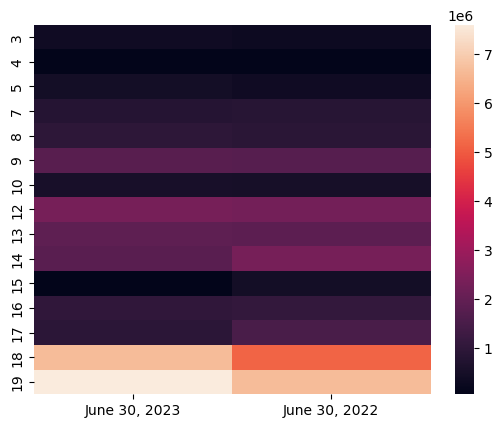

In [129]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
df_subset = df[["June 30, 2023", "June 30, 2022"]]

#create heatmap of dataframe
sns.heatmap(df_subset)
plt.show() #show heatmap

       June 30, 2023  June 30, 2022
count   1.500000e+01   1.500000e+01
mean    1.827888e+06   1.746877e+06
std     2.270066e+06   1.860407e+06
min     7.661600e+04   6.456500e+04
25%     5.076100e+05   4.891660e+05
50%     9.683120e+05   1.084334e+06
75%     1.856418e+06   2.081990e+06
max     7.603147e+06   6.682694e+06


<Axes: >

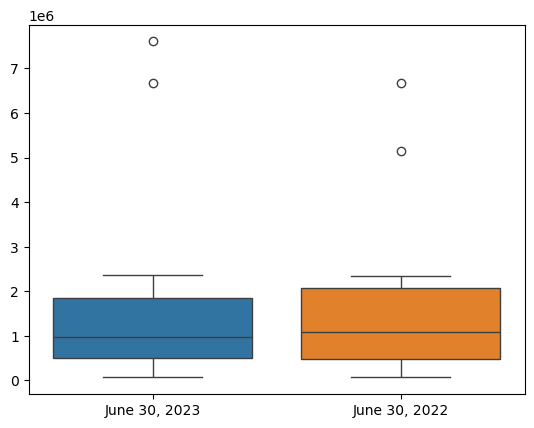

In [130]:
#find outliers in dataframe using describe()
print(df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=df)

In [131]:
#export budget 2023 net positions data csv file to processed-data folder
df.to_csv("../../data/processed-data/Budget2023_net_positions.csv")

In [132]:
#revenue_pdf_file = "../../data/raw-data/financial-statement-fy2023.pdf"

#extract revenue table from page 10 of the pdf file
revenue_table23 = camelot.read_pdf(pdf_file, flavor='stream', pages='10')

#if it is a table, then extract the second table from page 10
if revenue_table23:
    revenue23_df = revenue_table23[1].df
    print(revenue23_df)
else:
    print("no tables found")

                 0  1        2         3        4         5
0            2022:                                         
1                                Percent            Percent
2                         2023  of total     2022  of total
3              Bus  $   76,549    17 % $   62,305      16 %
4           Subway     176,521      39 %  172,174      45 %
5    Commuter rail     112,801      25 %   80,784      21 %
6  Other passenger      10,486       2 %    7,029       2 %
7  Other operating      76,616      17 %   64,565      16 %
8                   $  452,973   100 % $  386,857     100 %


In [133]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
revenue23_df.drop(1, axis=1, inplace=True)
#print(revenue23_df) #print dataframe to check columns dropped

In [134]:
#rename column headers in dataframe
revenue23_df.rename(columns={0:"Sources of Operating Revenue", 2:"June 30, 2023 Revenue", 3:"2023 Percent of Total Operating Revenue", 4:"June 30, 2022 Revenue", 5:"2022 Percent of Total Operating Revenue"}, inplace=True)
#print(revenue23_df)

In [135]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
revenue23_df.drop([0,1,2], inplace=True)
print(revenue23_df)

  Sources of Operating Revenue June 30, 2023 Revenue  \
3                          Bus                76,549   
4                       Subway               176,521   
5                Commuter rail               112,801   
6              Other passenger                10,486   
7              Other operating                76,616   
8                                            452,973   

  2023 Percent of Total Operating Revenue June 30, 2022 Revenue  \
3                                  17 % $                62,305   
4                                    39 %               172,174   
5                                    25 %                80,784   
6                                     2 %                 7,029   
7                                    17 %                64,565   
8                                 100 % $               386,857   

  2022 Percent of Total Operating Revenue  
3                                    16 %  
4                                    45 %  
5    

In [136]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
revenue23_df.at[8,"Sources of Operating Revenue"] = "Total Operating Revenue"
print(revenue23_df)


  Sources of Operating Revenue June 30, 2023 Revenue  \
3                          Bus                76,549   
4                       Subway               176,521   
5                Commuter rail               112,801   
6              Other passenger                10,486   
7              Other operating                76,616   
8      Total Operating Revenue               452,973   

  2023 Percent of Total Operating Revenue June 30, 2022 Revenue  \
3                                  17 % $                62,305   
4                                    39 %               172,174   
5                                    25 %                80,784   
6                                     2 %                 7,029   
7                                    17 %                64,565   
8                                 100 % $               386,857   

  2022 Percent of Total Operating Revenue  
3                                    16 %  
4                                    45 %  
5    

In [137]:
#strip white spaces, $ and % characters from values in the dataframe
revenue23_df["2023 Percent of Total Operating Revenue"] = revenue23_df["2023 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")
revenue23_df["2022 Percent of Total Operating Revenue"] = revenue23_df["2022 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")

revenue23_df["June 30, 2023 Revenue"] = revenue23_df["June 30, 2023 Revenue"].str.strip().str.replace(",", "")
revenue23_df["June 30, 2022 Revenue"] = revenue23_df["June 30, 2022 Revenue"].str.strip().str.replace(",", "")

print(revenue23_df)

### stop here for now 

  Sources of Operating Revenue June 30, 2023 Revenue  \
3                          Bus                 76549   
4                       Subway                176521   
5                Commuter rail                112801   
6              Other passenger                 10486   
7              Other operating                 76616   
8      Total Operating Revenue                452973   

  2023 Percent of Total Operating Revenue June 30, 2022 Revenue  \
3                                    17                   62305   
4                                     39                 172174   
5                                     25                  80784   
6                                      2                   7029   
7                                     17                  64565   
8                                   100                  386857   

  2022 Percent of Total Operating Revenue  
3                                     16   
4                                     45   
5    

In [138]:
print(revenue23_df.dtypes) #print the data types of columns in dataframe

revenue23_df["Sources of Operating Revenue"] = revenue23_df["Sources of Operating Revenue"].astype(str)
revenue23_df["June 30, 2023 Revenue"] = revenue23_df["June 30, 2023 Revenue"].astype(int)
revenue23_df["2023 Percent of Total Operating Revenue"] = revenue23_df["2023 Percent of Total Operating Revenue"].astype(int)
revenue23_df["June 30, 2022 Revenue"] = revenue23_df["June 30, 2022 Revenue"].astype(int)
revenue23_df["2022 Percent of Total Operating Revenue"] = revenue23_df["2022 Percent of Total Operating Revenue"].astype(int)

print("After data type conversion", revenue23_df.dtypes)


Sources of Operating Revenue               object
June 30, 2023 Revenue                      object
2023 Percent of Total Operating Revenue    object
June 30, 2022 Revenue                      object
2022 Percent of Total Operating Revenue    object
dtype: object
After data type conversion Sources of Operating Revenue               object
June 30, 2023 Revenue                       int64
2023 Percent of Total Operating Revenue     int64
June 30, 2022 Revenue                       int64
2022 Percent of Total Operating Revenue     int64
dtype: object


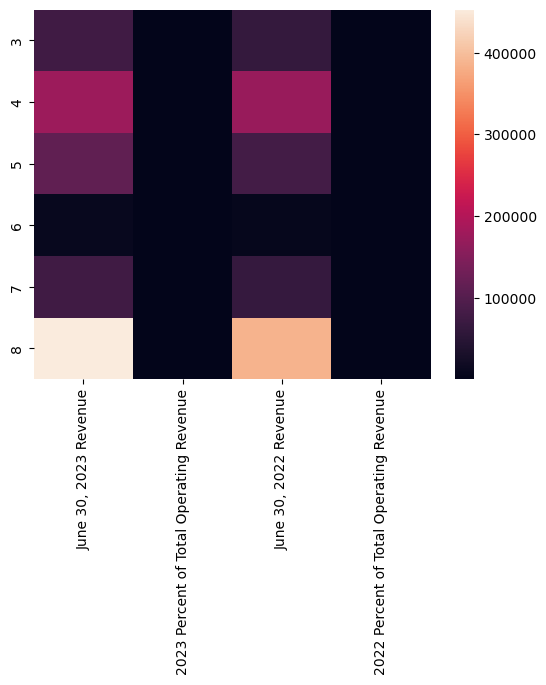

In [139]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
revenue23_df_subset = revenue23_df[[ "June 30, 2023 Revenue", "2023 Percent of Total Operating Revenue", "June 30, 2022 Revenue", "2022 Percent of Total Operating Revenue"]]

#create heatmap of dataframe
sns.heatmap(revenue23_df_subset)
plt.show() #show heatmap

       June 30, 2023 Revenue  2023 Percent of Total Operating Revenue  \
count               6.000000                                 6.000000   
mean           150991.000000                                33.333333   
std            157555.255284                                34.817620   
min             10486.000000                                 2.000000   
25%             76565.750000                                17.000000   
50%             94708.500000                                21.000000   
75%            160591.000000                                35.500000   
max            452973.000000                               100.000000   

       June 30, 2022 Revenue  2022 Percent of Total Operating Revenue  
count               6.000000                                 6.000000  
mean           128952.333333                                33.333333  
std            137226.828892                                35.539649  
min              7029.000000                          

<Axes: >

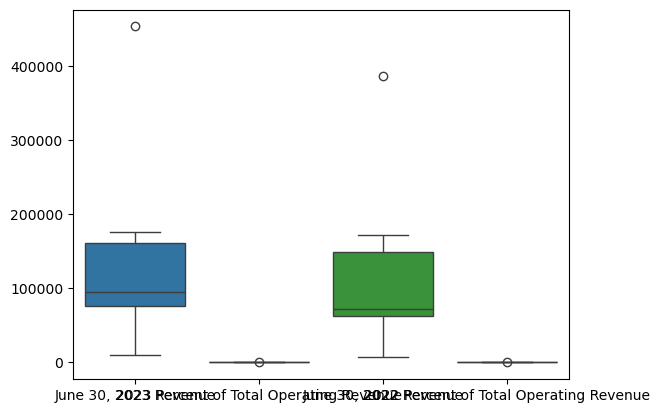

In [140]:
#find outliers in dataframe using describe()
print(revenue23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=revenue23_df)

In [141]:
#export cleaned 2023 operating revenue dataframe in csv file
revenue23_df.to_csv("../../data/processed-data/Budget2023_operating_revenue.csv")

In [142]:
#extract expenses table from pdf on page 11 using 'stream" because table data has no border
expenses_table = camelot.read_pdf(pdf_file, flavor='stream', pages='11')

#if it is a table and table is found, then extract table and convert the table into a dataframe
if expenses_table :
    expenses23_df = expenses_table[0].df
    print(expenses23_df)
else:
    print("no tables found")

                               0  1          2         3          4         5
0                      and 2022:                                             
1                                                Percent              Percent
2                                         2023  of total       2022  of total
3             Wages and benefits  $    822,671    35 % $    858,544      38 %
4                  Commuter rail       634,244      27 %    581,500      26 %
5  Depreciation and amortization       562,247      24 %    526,776      23 %
6          Material and supplies       304,646      13 %    283,548      12 %
7                Other operating        29,422       1 %     25,051       1 %
8                                 $  2,353,230   100 % $  2,275,419     100 %


In [143]:
#drop unneeded columns from the dataframe. Drop columns with default header 1
expenses23_df.drop(1, axis=1, inplace=True)
#print(expenses23_df) #print dataframe to check columns dropped

In [144]:
#rename column headers in dataframe
expenses23_df.rename(columns={0:"Sources of Operating Expenses", 2:"June 30, 2023 Expenses", 3:"2023 Percent of Total Operating Expenses", 4:"June 30, 2022 Expenses", 5:"2022 Percent of Total Operating Expenses"}, inplace=True)
#print(expenses23_df)

In [145]:
#drop rows indexes 0,1,2 because they had blank values and other rows were correctly renamed
expenses23_df.drop([0,1,2], inplace=True)
#print(expenses23_df)

In [146]:
#rename total value column "Sources of Operating Expenses" because the table was missing a label for the total operating expenses at bottom of dataframe
expenses23_df.at[8,"Sources of Operating Expenses"] = "Total Operating Expenses"
#print(expenses23_df)

In [147]:
#strip white spaces, $ and % characters from values in the dataframe
expenses23_df["2023 Percent of Total Operating Expenses"] = expenses23_df["2023 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")
expenses23_df["2022 Percent of Total Operating Expenses"] = expenses23_df["2022 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")

expenses23_df["June 30, 2023 Expenses"] = expenses23_df["June 30, 2023 Expenses"].str.strip().str.replace(",", "")
expenses23_df["June 30, 2022 Expenses"] = expenses23_df["June 30, 2022 Expenses"].str.strip().str.replace(",", "")

#print(expenses23_df)

In [148]:
print(expenses23_df.dtypes) #print the data types of columns in dataframe

expenses23_df["Sources of Operating Expenses"] = expenses23_df["Sources of Operating Expenses"].astype(str)
expenses23_df["June 30, 2023 Expenses"] = expenses23_df["June 30, 2023 Expenses"].astype(int)
expenses23_df["2023 Percent of Total Operating Expenses"] = expenses23_df["2023 Percent of Total Operating Expenses"].astype(int)
expenses23_df["June 30, 2022 Expenses"] = expenses23_df["June 30, 2022 Expenses"].astype(int)
expenses23_df["2022 Percent of Total Operating Expenses"] = expenses23_df["2022 Percent of Total Operating Expenses"].astype(int)

print("After data type conversion", expenses23_df.dtypes)

Sources of Operating Expenses               object
June 30, 2023 Expenses                      object
2023 Percent of Total Operating Expenses    object
June 30, 2022 Expenses                      object
2022 Percent of Total Operating Expenses    object
dtype: object
After data type conversion Sources of Operating Expenses               object
June 30, 2023 Expenses                       int64
2023 Percent of Total Operating Expenses     int64
June 30, 2022 Expenses                       int64
2022 Percent of Total Operating Expenses     int64
dtype: object


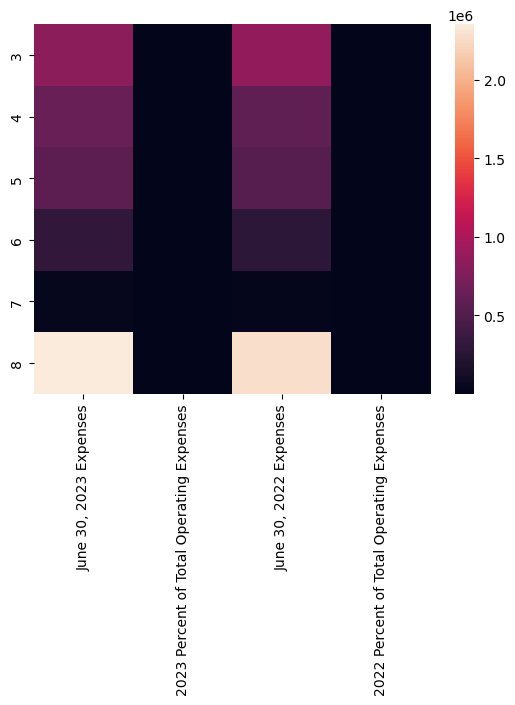

       June 30, 2023 Expenses  2023 Percent of Total Operating Expenses  \
count            6.000000e+00                                  6.000000   
mean             7.844100e+05                                 33.333333   
std              8.166697e+05                                 34.737108   
min              2.942200e+04                                  1.000000   
25%              3.690462e+05                                 15.750000   
50%              5.982455e+05                                 25.500000   
75%              7.755642e+05                                 33.000000   
max              2.353230e+06                                100.000000   

       June 30, 2022 Expenses  2022 Percent of Total Operating Expenses  
count            6.000000e+00                                  6.000000  
mean             7.584730e+05                                 33.333333  
std              7.949345e+05                                 35.006666  
min              2.505100e+0

<Axes: >

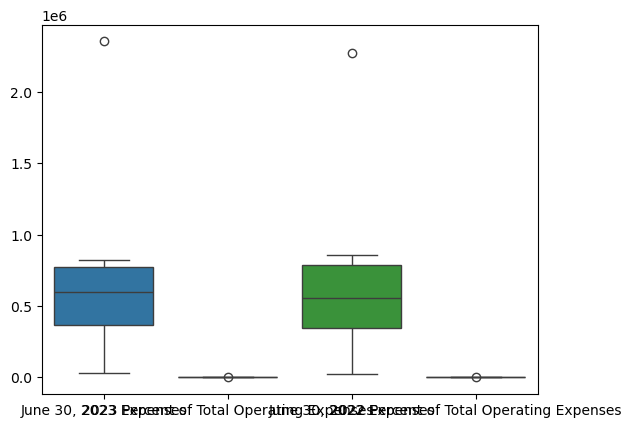

In [149]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
expenses23_df_subset = expenses23_df[[ "June 30, 2023 Expenses", "2023 Percent of Total Operating Expenses", "June 30, 2022 Expenses", "2022 Percent of Total Operating Expenses"]]

#create heatmap of dataframe
sns.heatmap(expenses23_df_subset)
plt.show() #show heatmap
 

#find outliers in dataframe using describe()
print(expenses23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=expenses23_df)

In [150]:
#export cleaned 2023 operating expenses dataframe in csv file
expenses23_df.to_csv("../../data/processed-data/Budget2023_operating_expenses.csv")



In [151]:
#extract debt table from pdf on page 12 using 'stream" because table data has no border
debt_table = camelot.read_pdf(pdf_file, flavor='stream', pages='12')

#if it is a table and table is found, then extract table and convert the table into a dataframe
if debt_table:
    debts23_df = debt_table[0].df
    print(debts23_df)
else:
    print("no tables found")

                                                   0  1          2  3  \
0  Bonds and notes outstanding for the fiscal yea...                    
1                                                             2023      
2                General Transportation System bonds  $     99,470  $   
3                                 Revenue bonds, net     4,248,525      
4                                              RRIFs       647,545      
5                                   Commercial paper       125,000      
6                                               BABs       394,300      
7                                                     $  5,514,840  $   

           4  
0             
1       2022  
2    110,210  
3  4,441,827  
4    370,392  
5     40,000  
6    402,550  
7  5,364,979  


In [152]:
#drop unneeded columns from the dataframe. Drop columns with default header 1
debts23_df.drop([1,3], axis=1, inplace=True)
print(debts23_df)

                                                   0          2          4
0  Bonds and notes outstanding for the fiscal yea...                      
1                                                          2023       2022
2                General Transportation System bonds     99,470    110,210
3                                 Revenue bonds, net  4,248,525  4,441,827
4                                              RRIFs    647,545    370,392
5                                   Commercial paper    125,000     40,000
6                                               BABs    394,300    402,550
7                                                     5,514,840  5,364,979


In [153]:
#rename column headers in dataframe
debts23_df.rename(columns={0:"Sources of Debt", 2:"June 30, 2023 Debt", 4:"June 30, 2022 Debt"}, inplace=True)


In [154]:
#drop rows indexes 0 because they had blank values and other rows were correctly renamed
debts23_df.drop(0, inplace=True)

In [155]:
#rename total value column "Sources of Debt" because the table was missing a label for the total debt at bottom of dataframe
debts23_df.at[7, "Sources of Debt"] = "Total Debt"


In [156]:
#strip white spaces, $ and % characters from values in the dataframe
debts23_df["June 30, 2023 Debt"] = debts23_df["June 30, 2023 Debt"].str.strip().str.replace(",", "")
debts23_df["June 30, 2022 Debt"] = debts23_df["June 30, 2022 Debt"].str.strip().str.replace(",", "")
#print(expenses23_df)

In [157]:
print(debts23_df.dtypes) #print the data types of columns in dataframe

debts23_df["Sources of Debt"] = debts23_df["Sources of Debt"].astype(str)
debts23_df["June 30, 2023 Debt"] = debts23_df["June 30, 2023 Debt"].astype(int)
debts23_df["June 30, 2022 Debt"] = debts23_df["June 30, 2022 Debt"].astype(int)

print("After data type conversion", debts23_df.dtypes)


Sources of Debt       object
June 30, 2023 Debt    object
June 30, 2022 Debt    object
dtype: object
After data type conversion Sources of Debt       object
June 30, 2023 Debt     int64
June 30, 2022 Debt     int64
dtype: object


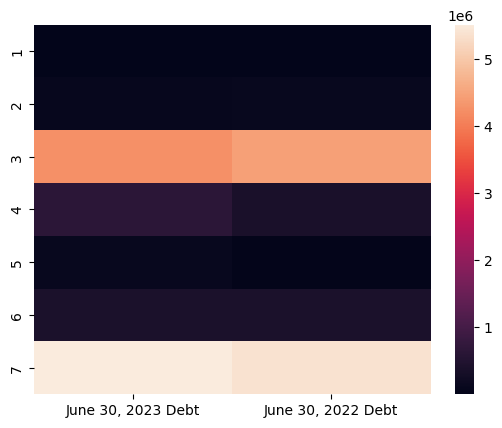

       June 30, 2023 Debt  June 30, 2022 Debt
count        7.000000e+00        7.000000e+00
mean         1.575958e+06        1.533140e+06
std          2.297761e+06        2.322792e+06
min          2.023000e+03        2.022000e+03
25%          1.122350e+05        7.510500e+04
50%          3.943000e+05        3.703920e+05
75%          2.448035e+06        2.422188e+06
max          5.514840e+06        5.364979e+06


<Axes: >

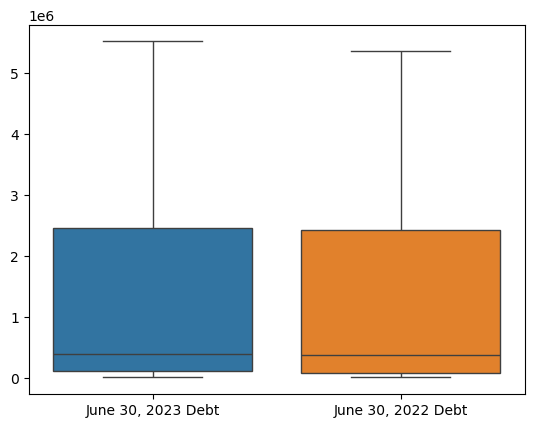

In [158]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
debts23_df_subset = debts23_df[["June 30, 2023 Debt", "June 30, 2022 Debt"]]

#create heatmap of dataframe
sns.heatmap(debts23_df_subset)
plt.show() #show heatmap
 

#find outliers in dataframe using describe()
print(debts23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=debts23_df)

In [159]:
#export cleaned 2023 debts dataframe in csv file
debts23_df.to_csv("../../data/processed-data/Budget2023_debts.csv")

In [162]:
#set pdf file path for the 2021 budget pdf file
pdf_file21 = "../../data/raw-data/fy21-audited-financial-statements.pdf"

#extract table from pdf on page 9 using 'stream" because table data has no border
table_file21_p1 = camelot.read_pdf(pdf_file21, flavor='stream', pages='7')

#if it is a table and table is found, then convert the table into a dataframe
if table_file21_p1:
    net21_p1_df = table_file21_p1[1].df
    print(net21_p1_df)
else:
    print("no tables found")

#extract table from pdf on page 9 using 'stream" because table data has no border
table_file21 = camelot.read_pdf(pdf_file21, flavor='stream', pages='8')

#if it is a table and table is found, then convert the table into a dataframe
if table_file21:
    net21_df = table_file21[0].df
    print(net21_df)
else:
    print("no tables found")

#stack the two dataframes using concat becuase the table was split into two pages on the pdf file
combined_net21_df = pd.concat([net21_p1_df, net21_df])

combined_net21_df_index = combined_net21_df.reset_index()

print(combined_net21_df_index)

DependencyError: PyCryptodome is required for AES algorithm

In [ ]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1 and 4
combined_net21_df_index.drop([1,4, "index"], axis=1, inplace=True)
#print(combined_net21_df) #print dataframe to check columns dropped

In [ ]:
#rename headers in dataframe
combined_net21_df_index.rename(columns={0:"Statements of Revenue, Expenses and Changes in Net Position", 2:"June 30, 2021", 3:"June 30, 2020"}, inplace=True)
print(combined_net21_df_index)

In [ ]:
#rename some values in the "Statements of Revenue, Expenses and Changes in Net Position" column because the table was formatted with too much space for those cells
combined_net21_df_index.at[4,"Statements of Revenue, Expenses and Changes in Net Position"] = "Other revenue"
combined_net21_df_index.at[13,"Statements of Revenue, Expenses and Changes in Net Position"] = "Total operating expenses, including depreciation and amortization"
print(combined_net21_df_index)

In [ ]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
combined_net21_df_index.drop([0,1,2,6,10,12], inplace=True)
print(combined_net21_df_index)

In [ ]:
#check the data types of columns in the dataframe
print(combined_net21_df_index.dtypes)
combined_net21_df_index["Statements of Revenue, Expenses and Changes in Net Position"] = combined_net21_df_index["Statements of Revenue, Expenses and Changes in Net Position"].astype(str) #transform data type from objects into strings in this column

combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].str.replace(",", "") #remove comma characters in column "June 30, 2021"
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].str.replace(",", "") #remove comma characters in column "June 30, 2020"

combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].str.replace("(", "") #remove '(' characters in column "June 30, 2021"
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].str.replace("(", "") #remove '(' characters in column "June 30, 2020"

combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].str.replace(")", "") #remove ')' characters in column "June 30, 2021"
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].str.replace(")", "") #remove ')' characters in column "June 30, 2020"


combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].astype(int) #convert "June 30, 2021" column data type to numeric
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].astype(int) #convert "June 30, 2020" column data type to numeric

print("After conversion", combined_net21_df_index.dtypes)

In [ ]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
combined_net21_df_index_subset = combined_net21_df_index[[ "June 30, 2021", "June 30, 2020"]]

#create heatmap of dataframe
sns.heatmap(combined_net21_df_index_subset)
plt.show() #show heatmap


#find outliers in dataframe using describe()
print(combined_net21_df_index.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=combined_net21_df_index)

In [ ]:
#export cleaned 2021-2020 debts dataframe in csv file
combined_net21_df_index.to_csv("../../data/processed-data/Budget2021_2020_net_positions.csv")

In [ ]:
#extract table from pdf on page 9 using 'stream" because table data has no border: revenue table
table21revenue = camelot.read_pdf(pdf_file21, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
if table21revenue:
    revenue21_df = table21revenue[0].df
    print("Revenue table 2021 \n", revenue21_df)
else:
    print("no tables found")

In [ ]:
#extract table from pdf on page 9 using 'stream" because table data has no border: expenses table
table21expenses = camelot.read_pdf(pdf_file21, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
if table21expenses:
    expenses21_df = table21expenses[1].df
    print("Expenses table 2021 \n", expenses21_df)
else:
    print("no tables found")


In [ ]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
revenue21_df = revenue21_df.drop(1, axis=1)
#print(revenue21_df) #print dataframe to check columns dropped

#rename column headers in dataframe
revenue21_df = revenue21_df.rename(columns={0:"Sources of Operating Revenue", 2:"June 30, 2021 Revenue", 3:"2021 Percent of Total Operating Revenue", 4:"June 30, 2020 Revenue", 5:"2020 Percent of Total Operating Revenue"})
#print(revenue21_df)

#drop rows indexs because they had blank values and other rows were correctly renamed
revenue21_df.drop([0,1,2], inplace=True)
print(revenue21_df)

In [ ]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
revenue21_df.at[8,"Sources of Operating Revenue"] = "Total Operating Revenue"
print(revenue21_df)


In [ ]:
#strip white spaces, $ and % characters from values in the dataframe
revenue21_df["2021 Percent of Total Operating Revenue"] = revenue21_df["2021 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")
revenue21_df["2020 Percent of Total Operating Revenue"] = revenue21_df["2020 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")

revenue21_df["June 30, 2021 Revenue"] = revenue21_df["June 30, 2021 Revenue"].str.strip().str.replace(",", "")
revenue21_df["June 30, 2020 Revenue"] = revenue21_df["June 30, 2020 Revenue"].str.strip().str.replace(",", "")
print(revenue21_df)

print(revenue21_df.dtypes) #print the data types of columns in dataframe
revenue21_df["Sources of Operating Revenue"] = revenue21_df["Sources of Operating Revenue"].astype(str)
revenue21_df["June 30, 2021 Revenue"] = revenue21_df["June 30, 2021 Revenue"].astype(int)
revenue21_df["2021 Percent of Total Operating Revenue"] = revenue21_df["2021 Percent of Total Operating Revenue"].astype(int)
revenue21_df["June 30, 2020 Revenue"] = revenue21_df["June 30, 2020 Revenue"].astype(int)
revenue21_df["2020 Percent of Total Operating Revenue"] = revenue21_df["2020 Percent of Total Operating Revenue"].astype(int)

print("After data type conversion", revenue21_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
revenue21_df_subset = revenue21_df[["June 30, 2021 Revenue", "2021 Percent of Total Operating Revenue", "June 30, 2020 Revenue", "2020 Percent of Total Operating Revenue"]]

#create heatmap of dataframe
sns.heatmap(revenue21_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(revenue21_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=revenue21_df)

In [ ]:
#export cleaned 2021-2020 revenue dataframe in csv file
revenue21_df.to_csv("../../data/processed-data/Budget2021_2020_revenue.csv")

In [ ]:
#2021-2020 expenses
#drop unneeded columns from the df dataframe. Drop columns with default header 1
expenses21_df = expenses21_df.drop(1, axis=1)

#rename column headers in dataframe
expenses21_df = expenses21_df.rename(columns={0:"Sources of Operating Expenses", 2:"June 30, 2021 Expenses", 3:"2021 Percent of Total Operating Expenses", 4:"June 30, 2020 Expenses", 5:"2020 Percent of Total Operating Expenses"})
print(expenses21_df)

In [ ]:
#drop rows indexs because they had blank values and other rows were correctly renamed
expenses21_df.drop([0,1,2], inplace=True)
#print(expenses21_df)

In [ ]:
#rename some values in the "Sources of Operating Expenses" column because the table was formatted with too much space for those cells
expenses21_df.at[8,"Sources of Operating Expenses"] = "Total Operating Expenses"
#print(expenses21_df)

In [ ]:
#strip white spaces, $ and % characters from values in the dataframe
expenses21_df["2021 Percent of Total Operating Expenses"] = expenses21_df["2021 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")
expenses21_df["2020 Percent of Total Operating Expenses"] = expenses21_df["2020 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")

expenses21_df["June 30, 2021 Expenses"] = expenses21_df["June 30, 2021 Expenses"].str.strip().str.replace(",", "")
expenses21_df["June 30, 2020 Expenses"] = expenses21_df["June 30, 2020 Expenses"].str.strip().str.replace(",", "")

print(expenses21_df.dtypes) #print the data types of columns in dataframe
expenses21_df["Sources of Operating Expenses"] = expenses21_df["Sources of Operating Expenses"].astype(str)
expenses21_df["June 30, 2021 Expenses"] = expenses21_df["June 30, 2021 Expenses"].astype(int)
expenses21_df["2021 Percent of Total Operating Expenses"] = expenses21_df["2021 Percent of Total Operating Expenses"].astype(int)
expenses21_df["June 30, 2020 Expenses"] = expenses21_df["June 30, 2020 Expenses"].astype(int)
expenses21_df["2020 Percent of Total Operating Expenses"] = expenses21_df["2020 Percent of Total Operating Expenses"].astype(int)

print("After data type conversion", expenses21_df.dtypes)

print(expenses21_df)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
expenses21_df_subset = expenses21_df[["June 30, 2021 Expenses", "2021 Percent of Total Operating Expenses", "June 30, 2020 Expenses", "2020 Percent of Total Operating Expenses"]]

#create heatmap of dataframe
sns.heatmap(expenses21_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(expenses21_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=expenses21_df)

In [ ]:
#export cleaned 2021-2020 expenses dataframe in csv file
expenses21_df.to_csv("../../data/processed-data/Budget2021_2020_expenses.csv")

In [ ]:
#extract debt table for 2021 from the 2022 financial statement audit because library was not able to correctly extract debt table from the 2021 financial statement pdf file.

#set pdf file path for the 2022 budget pdf file
pdf_file22 = "../../data/raw-data/fy22-audited-financial-statement.pdf"

#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table21debts = camelot.read_pdf(pdf_file22, flavor='stream', pages='11')

#if it is a table and table is found, then convert the table into a dataframe
if table21debts:
    debts21_df = table21debts[0].df
    print(debts21_df)
else:
    print("no tables found")

In [ ]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
#drop 2022 since that was already extracted in the previous part of the code
debts21_df = debts21_df.drop([1,2], axis=1)
#print(debts21_df)

In [ ]:
#rename column headers in dataframe
debts21_df = debts21_df.rename(columns={0:"Sources of Debt", 3:"June 30, 2021 Debts"})
#print(debts21_df)

In [ ]:
#drop rows indexs because they had blank values and other rows were correctly renamed
debts21_df.drop([0,1,2], inplace=True)
#print(debts21_df)

In [ ]:
#rename some values in the "Sources of Debt" column because the table was formatted with too much space for those cells
debts21_df.at[8,"Sources of Debt"] = "Total Debts"
print(debts21_df)

In [ ]:
#strip white spaces and comma characters from values in the dataframe
#debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].str.strip().replace('—',np.nan)

#decided to replace missing value with "0" to convert column to integers and keep row count the same for eaiser joining later on with other dataframes
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].str.strip().replace('—',np.nan)
#debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].fillna(0)

print(debts21_df)

In [ ]:
#strip white spaces and comma characters from values in the dataframe
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].str.strip().str.replace(",", "")
print(debts21_df)

print(debts21_df.dtypes) #print the data types of columns in dataframe
debts21_df["Sources of Debt"] = debts21_df["Sources of Debt"].astype(str)
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].astype(float)
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].fillna(0).astype(int)
print("After data type conversion", debts21_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
debts21_df_subset = debts21_df[[ "June 30, 2021 Debts"]]

#create heatmap of dataframe
sns.heatmap(debts21_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(debts21_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=debts21_df)

In [ ]:
debts21_df.to_csv("../../data/processed-data/Budget2021_debts.csv")

In [ ]:
#extract net position table for 2020 and 2019 from the 2020 financial statement audit

#set pdf file path for the 2022 budget pdf file
pdf_file20 = "../../data/raw-data/fy20-financial-audit.pdf"

#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table20_net = camelot.read_pdf(pdf_file20, flavor='stream', pages='8')

#if it is a table and table is found, then convert the table into a dataframe
if table20_net:
    net20_df = table20_net [0].df
    print(net20_df)
else:
    print("no tables found")

In [ ]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
net20_df = net20_df.drop([1,2], axis=1)

#rename column headers in dataframe
net20_df = net20_df.rename(columns={0:"Statements of Revenue, Expenses and Changes in Net Position", 3:"June 30, 2019 Net Positions"})

#drop rows indexs because they had blank values and other rows were correctly renamed
net20_df = net20_df.drop([0,1,2,6,11])
print(net20_df)


In [ ]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
net20_df.at[4,"Statements of Revenue, Expenses and Changes in Net Position"] = "Other Revenue"
net20_df.at[12,"Statements of Revenue, Expenses and Changes in Net Position"] = "Total operating expenses, including depreciation and amortization"
print(net20_df)

In [ ]:
#strip white spaces and comma characters from values in the dataframe
net20_df["June 30, 2019 Net Positions"] = net20_df["June 30, 2019 Net Positions"].str.strip().str.replace(",", "").str.replace("(", "").str.replace(")", "")
print(net20_df)

print(net20_df.dtypes) #print the data types of columns in dataframe
net20_df["Statements of Revenue, Expenses and Changes in Net Position"] = net20_df["Statements of Revenue, Expenses and Changes in Net Position"].astype(str)
net20_df["June 30, 2019 Net Positions"] = net20_df["June 30, 2019 Net Positions"].astype(int)
print("After data type conversion", net20_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
net20_df_subset = net20_df[["June 30, 2019 Net Positions"]]

#create heatmap of dataframe
sns.heatmap(net20_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(net20_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=net20_df)

In [ ]:
#export cleaned 2019 net positions dataframe to csv file
net20_df.to_csv("../../data/processed-data/Budget2019_net_positions.csv")

In [ ]:
#not able to get revenue table for 2019 because the camelot library was only able to extract the first half of the page which was the text instead of the table.
#set pdf file path for the 2019 budget pdf file
pdf_file19 = "../../data/raw-data/2019-06-30-fy19-financial-audit.pdf"

#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table19_revenue = camelot.read_pdf(pdf_file19, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
#if table19_revenue:
    #revenue19_df = table19_revenue[1].df
    #print(revenue19_df)
#else:
    #print("no tables found")

In [ ]:
#extract expenses for 2019
#extract table from pdf on page 10 using 'stream" because table data has no border
table19_expenses = camelot.read_pdf(pdf_file20, flavor='stream', pages='10')

#if it is a table and table is found, then convert the table into a dataframe
if table19_expenses:
    expenses19_df = table19_expenses[0].df
    print(expenses19_df)
else:
    print("no tables found")

In [ ]:
#drop unneeded columns from the df dataframe
expenses19_df = expenses19_df.drop([1,2,3], axis=1)

#rename column headers in dataframe
expenses19_df = expenses19_df.rename(columns={0:"Sources of Operating Expenses", 4:"June 30, 2019 Expenses", 5:"2019 Percent of Total Operating Expenses"})

#drop rows indexs because they had blank values and other rows were correctly renamed
expenses19_df = expenses19_df.drop([0,1,2])
print(expenses19_df)

In [ ]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
expenses19_df.at[8,"Sources of Operating Expenses"] = "Total Operating Expenses"

In [ ]:
#strip white spaces, commas, and % characters from values in the dataframe
expenses19_df["2019 Percent of Total Operating Expenses"] = expenses19_df["2019 Percent of Total Operating Expenses"].str.strip().str.replace("%", "")
expenses19_df["June 30, 2019 Expenses"] = expenses19_df["June 30, 2019 Expenses"].str.strip().str.replace(",", "")
print(expenses19_df)

print(expenses19_df.dtypes) #print the data types of columns in dataframe
expenses19_df["Sources of Operating Expenses"] = expenses19_df["Sources of Operating Expenses"].astype(str)
expenses19_df["2019 Percent of Total Operating Expenses"] = expenses19_df["2019 Percent of Total Operating Expenses"].astype(int)
expenses19_df["June 30, 2019 Expenses"] = expenses19_df["June 30, 2019 Expenses"].astype(int)

print("After data type conversion", expenses19_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
expenses19_df_subset = expenses19_df[["2019 Percent of Total Operating Expenses", "June 30, 2019 Expenses"]]

#create heatmap of dataframe
sns.heatmap(expenses19_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(expenses19_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=expenses19_df)

In [ ]:
#export cleaned 2019 expenses dataframe into csv file
expenses19_df.to_csv("../../data/processed-data/Budget2019_expenses.csv")

In [ ]:
#keep both 2020 and 2019 for debts from the 2020 financial file
#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table20_19_debts = camelot.read_pdf(pdf_file20, flavor='stream', pages='11')

#if it is a table and table is found, then convert the table into a dataframe
if table20_19_debts:
    debts20_19_df = table20_19_debts[0].df
    print(debts20_19_df)
else:
    print("no tables found")

In [ ]:
#drop unneeded columns from the df dataframe
debts20_19_df = debts20_19_df.drop(1, axis=1)

#rename column headers in dataframe
debts20_19_df = debts20_19_df.rename(columns={0:"Sources of Debt", 2:"June 30, 2020 Debt", 3:"June 30, 2019 Debt"})

#drop rows indexs because they had blank values and other rows were correctly renamed
debts20_19_df = debts20_19_df.drop([0,1,2])
print(debts20_19_df)

In [ ]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
debts20_19_df.at[7,"Sources of Debt"] = "Total Debts"

In [ ]:
#strip white spaces and comma characters from values in the dataframe
debts20_19_df["June 30, 2020 Debt"] = debts20_19_df["June 30, 2020 Debt"].str.strip().str.replace(",", "")
debts20_19_df["June 30, 2019 Debt"] = debts20_19_df["June 30, 2019 Debt"].str.strip().str.replace(",", "")
print(debts20_19_df)

print(debts20_19_df.dtypes) #print the data types of columns in dataframe
debts20_19_df["Sources of Debt"] = debts20_19_df["Sources of Debt"].astype(str)
debts20_19_df["June 30, 2020 Debt"] = debts20_19_df["June 30, 2020 Debt"].astype(int)
debts20_19_df["June 30, 2019 Debt"] = debts20_19_df["June 30, 2019 Debt"].astype(int)

print("After data type conversion", debts20_19_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
debts20_19_df_subset = debts20_19_df[["June 30, 2020 Debt", "June 30, 2019 Debt"]]

#create heatmap of dataframe
sns.heatmap(debts20_19_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(debts20_19_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=debts20_19_df)

In [ ]:
#export cleaned 2019 and 2020 debts dataframe into csv file
debts20_19_df.to_csv("../../data/processed-data/Budget2019_2020_debts.csv")

In [ ]:
#join dataframes for net positions from 2023 to 2019
#join on common column "Statements of Revenue, Expenses and Changes in Net Position
net_join = pd.merge(df, combined_net21_df_index, on="Statements of Revenue, Expenses and Changes in Net Position")
#net_join = df.join(combined_net21_df_index, how='left')
#print(net_join) #check first join

net_join2 = pd.merge(net_join, net20_df, on="Statements of Revenue, Expenses and Changes in Net Position")
print(net_join2)

In [ ]:
#rename column headers to prepare for melt function
net_join2_rename = net_join2.rename(columns={"June 30, 2023":"2023-06-30", "June 30, 2022":"2022-06-30", "June 30, 2021":"2021-06-30", "June 30, 2020":"2020-06-30", "June 30, 2019 Net Positions":"2019-06-30"})


In [ ]:
#melt the joined net position dataframe to join with the ride reliability dataset on date column
melt_net_positions = net_join2_rename.melt(id_vars=["Statements of Revenue, Expenses and Changes in Net Position"], var_name='Date', value_name="Net Position Amounts (USD)")
#print(melt_net_positions)


In [ ]:
#load the clean ride reliability dataset to join with the net position dataset
reliability = pd.read_csv("../../data/processed-data/Clean_Ride_Reliability.csv")

#convert csv file into a dataframe
reliability_df = pd.DataFrame(reliability)

#print(reliability_df.head())

#drop unneeded columns from the df dataframe
reliability_df_drop = reliability_df.drop(["Unnamed: 0", "trip_date", "ObjectId"], axis=1)

print(reliability_df_drop.head())

In [ ]:
#join the joined net position dataframe with the ride reliability dataframe on the "Date" column
#net_position_reliabiity_df = pd.merge(melt_net_positions, reliability_df_drop, left_on=None)
net_position_reliabiity_df = melt_net_positions.join(reliability_df_drop, how='inner') #dates and date

#net_position_reliabiity_df = pd.concat([melt_net_positions, reliability_df_drop]) #joined but just stacked

print(net_position_reliabiity_df)

In [ ]:
#export joined dataframe to csv as test file
net_position_reliabiity_df.to_csv("../../data/processed-data/Net_positions_reliability.csv")

In [ ]:
#test attempt convert date to datetime in both datasets
#this attempt merged the two dataframes together correctly!
melt_net_positions["Date"] = pd.to_datetime(melt_net_positions["Date"])
reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_net = pd.merge(melt_net_positions, reliability_df_drop, on="Date", how="inner")
print(merged_net)

In [ ]:
#export joined dataframe to csv as test file
merged_net.to_csv("../../data/processed-data/attempt2_Net_positions_reliability.csv")

In [ ]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_net_binary = merged_net

print(merged_net_binary["Date"].dtype) #check if column is datatime type

#we want to observe all dates after 2022-06-30-01 as "1"'s and all dates before 2022-06-30 as "0"'s
#split the data pre and post 2022-01-01 because that was the year the MBTA infrastructure renovation program began. Since this dataset only has the 6/30/2022 date, we will use that data as the benchmark for binary analysis
date_to_string = "2022-06-30" #set variable to 2022-06-30 to find its numeric format
date_convert = datetime.strptime(date_to_string, "%Y-%m-%d") #convert string date to datetime format
print(type(date_convert)) #check if it is datetime format
num_date = int(date_convert.timestamp()) #convert datetime to an integer
#num_date_result = num_date//10**9
#print(num_date_result)
print(num_date) #print the numeric conversion of the 2022-01-01 date which equals 1641013200, easier for if else statement to transform dates into binary values

merged_net_binary["Pre and Post 2021"] = merged_net_binary["Date"].astype('int64')//10**9 #convert dates in the "weekly" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_net_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

merged_net_binary["Pre and Post 2021 Binary"] = np.where(merged_net_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_net_binary.head()) #print first few rows of binary dates


In [ ]:
#export joined dataframe to csv file
merged_net_binary.to_csv("../../data/processed-data/Net_positions_reliability_binary.csv")

In [ ]:
#join dataframes for revenue
merged_revenue = pd.merge(revenue23_df,revenue21_df, on="Sources of Operating Revenue")
print(merged_revenue)

In [ ]:
#rename columns
merged_revenue_rename = merged_revenue.rename(columns={"June 30, 2023 Revenue":"2023-06-30", "June 30, 2022 Revenue":"2022-06-30", "June 30, 2021 Revenue":"2021-06-30", "June 30, 2020 Revenue":"2020-06-30"})

#drop the percent of total operating revenue columns to make melt function easier
merged_revenue_drop = merged_revenue_rename.drop(["2023 Percent of Total Operating Revenue", "2022 Percent of Total Operating Revenue", "2021 Percent of Total Operating Revenue", "2020 Percent of Total Operating Revenue"], axis=1)

#melt the joined revenue dataframe to join with the ride reliability dataset on date column
melt_revenue = merged_revenue_drop.melt(id_vars=["Sources of Operating Revenue"], var_name='Date', value_name="Revenue (USD)")
print(melt_revenue)

In [ ]:
melt_revenue["Date"] = pd.to_datetime(melt_revenue["Date"])
#reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_rev_rel = pd.merge(melt_revenue, reliability_df_drop, on="Date", how="inner")
print(merged_rev_rel)

In [ ]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_revenue_binary = merged_rev_rel

print(merged_revenue_binary["Date"].dtype) #check if column is datatime type

#we want to observe all dates after 2022-06-30-01 as "1"'s and all dates before 2022-06-30 as "0"'s
#split the data pre and post 2022-01-01 because that was the year the MBTA infrastructure renovation program began. Since this dataset only has the 6/30/2022 date, we will use that data as the benchmark for binary analysis
#date_to_string = "2022-06-30" #set variable to 2022-06-30 to find its numeric format
#date_convert = datetime.strptime(date_to_string, "%Y-%m-%d") #convert string date to datetime format
#print(type(date_convert)) #check if it is datetime format
#num_date = int(date_convert.timestamp()) #convert datetime to an integer
#num_date_result = num_date//10**9
#print(num_date_result)
#print(num_date) #print the numeric conversion of the 2022-06-30, easier for if else statement to transform dates into binary values

merged_revenue_binary["Pre and Post 2021"] = merged_revenue_binary["Date"].astype('int64')//10**9 #convert dates in the "weekly" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_revenue_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

#num_date variable was set to 2022-06-30 from previous merge of dataframes
merged_revenue_binary["Pre and Post 2021 Binary"] = np.where(merged_revenue_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_revenue_binary.head()) #print first few rows of binary dates

In [ ]:
#export joined dataframe to csv file
merged_revenue_binary.to_csv("../../data/processed-data/Revenue_reliability_binary.csv")

In [ ]:
#merge all the dataframes for expenses
expenses_merged = pd.merge(expenses23_df, expenses21_df, on="Sources of Operating Expenses")
#print(expenses_merged)
expenses_merged2 = pd.merge(expenses_merged , expenses19_df, on="Sources of Operating Expenses")
print(expenses_merged2.head())

In [ ]:
#rename columns
expenses_merged2_rename = expenses_merged2.rename(columns={"June 30, 2023 Expenses":"2023-06-30", "June 30, 2022 Expenses":"2022-06-30", "June 30, 2021 Expenses":"2021-06-30", "June 30, 2020 Expenses":"2020-06-30", "June 30, 2019 Expenses":"2019-06-30"})

#drop the percent of total operating expenses columns to make melt function easier
expenses_merged2_drop = expenses_merged2_rename.drop(["2023 Percent of Total Operating Expenses", "2022 Percent of Total Operating Expenses", "2021 Percent of Total Operating Expenses", "2020 Percent of Total Operating Expenses", "2019 Percent of Total Operating Expenses"], axis=1)

#melt the joined revenue dataframe to join with the ride reliability dataset on date column
melt_expenses = expenses_merged2_drop.melt(id_vars=["Sources of Operating Expenses"], var_name='Date', value_name="Expenses (USD)")
print(melt_expenses.head())

In [ ]:
melt_expenses["Date"] = pd.to_datetime(melt_expenses["Date"])
#reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_expenses_rel = pd.merge(melt_expenses, reliability_df_drop, on="Date", how="inner")
print(merged_expenses_rel.head())

In [ ]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_expenses_rel_binary = merged_expenses_rel

print(merged_expenses_rel_binary["Date"].dtype) #check if column is datatime type

merged_expenses_rel_binary["Pre and Post 2021"] = merged_expenses_rel_binary["Date"].astype('int64')//10**9 #convert dates in the "Date" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_expenses_rel_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

#num_date variable was set to 2022-06-30 from previous merge of dataframes
merged_expenses_rel_binary["Pre and Post 2021 Binary"] = np.where(merged_expenses_rel_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_expenses_rel_binary.head()) #print first few rows of binary dates

In [ ]:
#export joined dataframe to csv file
merged_expenses_rel_binary.to_csv("../../data/processed-data/Expenses_reliability_binary.csv")

In [ ]:
#merge all the dataframes for debts
debts_merged = pd.merge(debts23_df, debts21_df, on="Sources of Debt")
#print(debts_merged)
debts_merged2 = pd.merge(debts_merged , debts20_19_df, on="Sources of Debt")
print(debts_merged2.head())

In [ ]:
#rename columns
debts_merged2_rename = debts_merged2.rename(columns={"June 30, 2023 Debt":"2023-06-30", "June 30, 2022 Debt":"2022-06-30", "June 30, 2021 Debts":"2021-06-30", "June 30, 2020 Debt":"2020-06-30", "June 30, 2019 Debt":"2019-06-30"})

#melt the joined revenue dataframe to join with the ride reliability dataset on date column
melt_debts = debts_merged2_rename.melt(id_vars=["Sources of Debt"], var_name='Date', value_name="Debt (USD)")
print(melt_debts.head())

In [ ]:
melt_debts["Date"] = pd.to_datetime(melt_debts["Date"])
#reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_debts_rel = pd.merge(melt_debts, reliability_df_drop, on="Date", how="inner")
print(merged_debts_rel.head())

In [ ]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_debts_rel_binary = merged_debts_rel

print(merged_debts_rel_binary["Date"].dtype) #check if column is datatime type

merged_debts_rel_binary["Pre and Post 2021"] = merged_debts_rel_binary["Date"].astype('int64')//10**9 #convert dates in the "Date" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_debts_rel_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

#num_date variable was set to 2022-06-30 from previous merge of dataframes
merged_debts_rel_binary["Pre and Post 2021 Binary"] = np.where(merged_debts_rel_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_debts_rel_binary.head()) #print first few rows of binary dates

In [ ]:
#export joined dataframe to csv file
merged_debts_rel_binary.to_csv("../../data/processed-data/Debts_reliability_binary.csv")